In [23]:
import numpy as np
import pandas as pd
import yfinance as yf
import warnings
from arch import arch_model
from hmmlearn.hmm import GaussianHMM
from scipy.optimize import minimize
from scipy.stats import norm
from tabulate import tabulate
from sklearn.preprocessing import StandardScaler

In [45]:
tickers = ['TCS.NS']
raw = yf.download(tickers, period='5y', interval='1d', auto_adjust=True, progress=False)


In [11]:
results = {}

In [39]:
for ticker in raw: 
    df = raw[ticker].pct_change().to_frame(name="ret")

    df["roll_vol"] = df["ret"].rolling(5).std().bfill()

    # Drop all NaNs together (important)
    df = df.dropna()

    features = df[["ret", "roll_vol"]].values

    features = StandardScaler().fit_transform(features)

    hmm = GaussianHMM(
        n_components=3,
        covariance_type="diag",
        n_iter=2000,
        tol=1e-5,
        random_state=42,
    )

    hmm.fit(features)
    states_seq = hmm.predict(features)

    # Label states by mean return and volatility
    state_mean_ret = {}
    state_vol = {}
    for s in range(3):
        mask = states_seq == s
        state_mean_ret[s] = ret[mask].mean() if mask.sum() > 0 else 0.0
        state_vol[s] = ret[mask].std() if mask.sum() > 0 else 0.0

    state_score = {}
    for s in range(3):
        # normalize both metrics
        ret_norm = (state_mean_ret[s] - np.mean(list(state_mean_ret.values())))
        vol_norm = (state_vol[s] - np.mean(list(state_vol.values())))
    
        # higher return good, higher vol bad
        state_score[s] = ret_norm - vol_norm

    sorted_states = sorted(state_score.items(), key=lambda x: x[1])

    bear_state = sorted_states[0][0]
    side_state = sorted_states[1][0]
    bull_state = sorted_states[2][0]

    label_map = {bear_state: "Bear", side_state: "Sideways", bull_state: "Bull"}
    current_label = label_map[states_seq[-1]]

    # Transition probabilities from current state
    current_state_id = states_seq[-1]
    trans_probs = hmm.transmat_[current_state_id]
    trans_named = {label_map[i]: round(trans_probs[i], 3) for i in range(3)}

    results[ticker] = {
        "regime": current_label,
        "regime_mean_daily": state_mean_ret[states_seq[-1]],
        "state_means": {label_map[s]: state_mean_ret[s] for s in range(3)},
        "transition_probs": trans_named,  # probability of staying in / leaving regime
        "history": [label_map[s] for s in states_seq],
    }


In [46]:
raw.head()

Price,Close,High,Low,Open,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
Date,,,,,
2021-04-06,2869.921875,2878.976409,2839.417954,2878.976409,2291562
2021-04-07,2875.811768,2881.218219,2843.637685,2864.911301,2491268
2021-04-08,2916.206299,2931.721923,2871.109604,2874.581915,2578118
2021-04-09,2920.513916,2948.732377,2907.987067,2948.424614,2911129
2021-04-12,2853.967529,2934.447073,2824.650225,2920.513616,3791828


In [171]:
returns = np.log(raw['Close']).diff()

In [172]:
returns.dropna(inplace=True)

In [174]:
returns = returns.squeeze()

<Axes: >

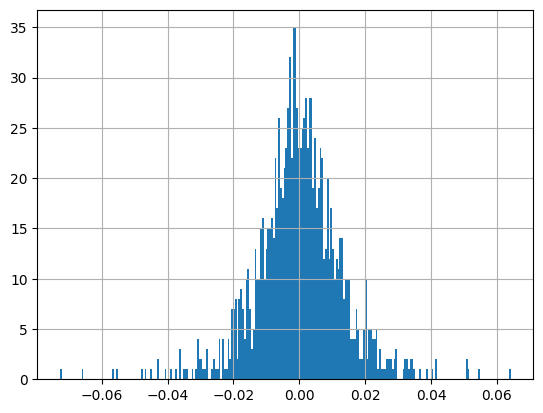

In [175]:
returns.hist(bins=250)

In [176]:
model = GaussianHMM(n_components=3, covariance_type='diag')

In [177]:
X = returns.to_numpy().reshape(-1,1)

In [178]:
X

array([[0.00205018],
       [0.01394857],
       [0.00147604],
       ...,
       [0.02068419],
       [0.01749412],
       [0.00942214]], shape=(1235, 1))

In [179]:
model.fit(X)

,n_components,3
,covariance_type,'diag'
,min_covar,0.001
,startprob_prior,1.0
,transmat_prior,1.0
,means_prior,0
,means_weight,0
,covars_prior,0.01
,covars_weight,1
,algorithm,'viterbi'
,random_state,None


In [180]:
Z = model.predict(X)

In [181]:
Z

array([1, 1, 1, ..., 1, 1, 1], shape=(1235,))

In [134]:
import matplotlib.pyplot as plt


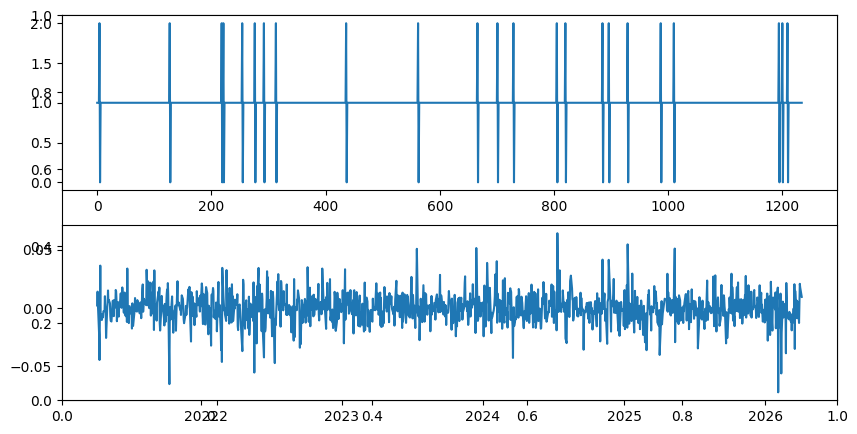

In [182]:
fig, ax = plt.subplots(figsize=(10, 5))
plt.subplot(211)
plt.plot(Z)
plt.subplot(212)
plt.plot(returns);

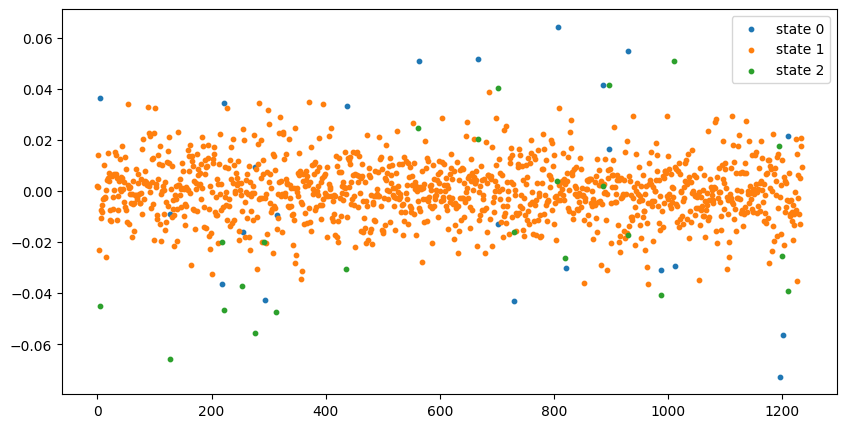

In [183]:
fig, ax = plt.subplots(figsize=(10, 5))

for state in np.unique(Z):
    mask = Z == state
    ax.scatter(np.where(mask), returns[mask], label=f'state {state}', s=10)

ax.legend()

Text(0.5, 1.0, 'State sequence')

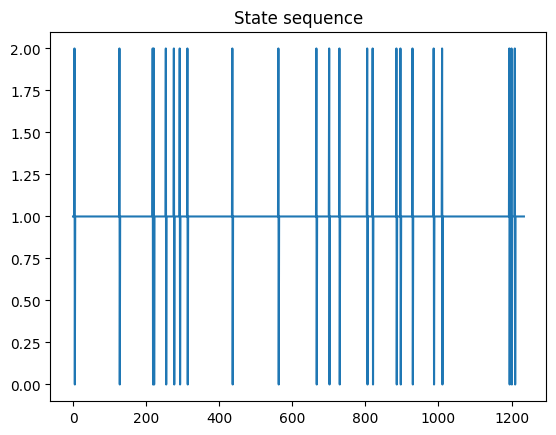

In [184]:
plt.plot(Z)
plt.title("State sequence")

In [167]:
model.transmat_

array([[6.55277349e-02, 5.78349117e-01, 3.56123148e-01],
       [2.38409168e-02, 1.57155299e-01, 8.19003784e-01],
       [5.19807187e-02, 9.47134399e-01, 8.84881921e-04]])

In [186]:
# try to set the transition matrix intuitively
model.transmat_ = np.array([
  [0.8, 0.2],
  [0.2, 0.8],
])

In [187]:
Z = model.predict(X)

ValueError: transmat_ must have shape (n_components, n_components)

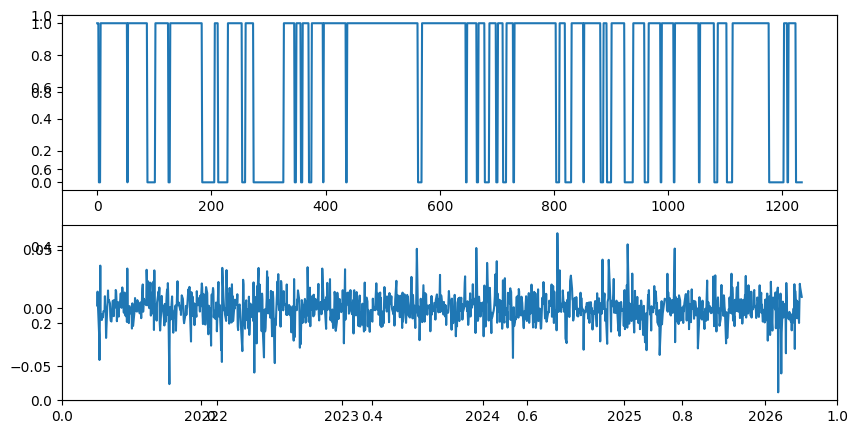

In [152]:
fig, ax = plt.subplots(figsize=(10, 5))
plt.subplot(211)
plt.plot(Z)
plt.subplot(212)
plt.plot(returns);

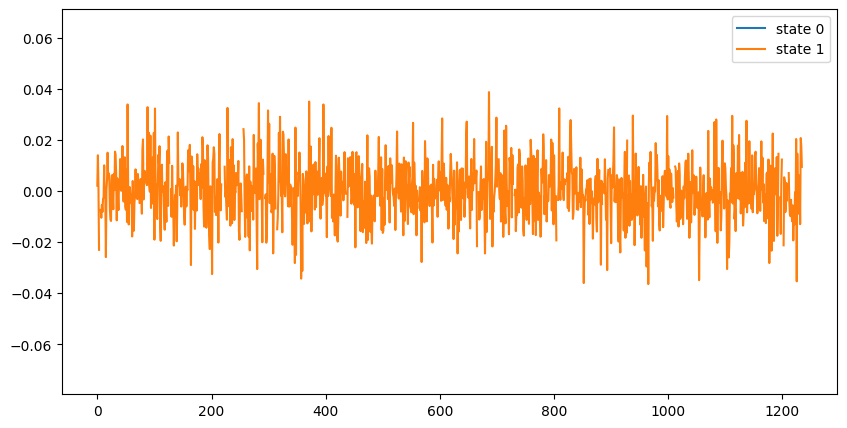

In [185]:
# we want to draw different segments in different colors according to state
fig, ax = plt.subplots(figsize=(10, 5))

# first create arrays with nan
returns0 = np.empty(len(Z))
returns1 = np.empty(len(Z))
returns0[:] = np.nan
returns1[:] = np.nan

# fill in the values only if the state is the one corresponding to the array
returns0[Z == 0] = returns[Z == 0]
returns1[Z == 1] = returns[Z == 1]
plt.plot(returns0, label='state 0')
plt.plot(returns1, label='state 1')
plt.legend();